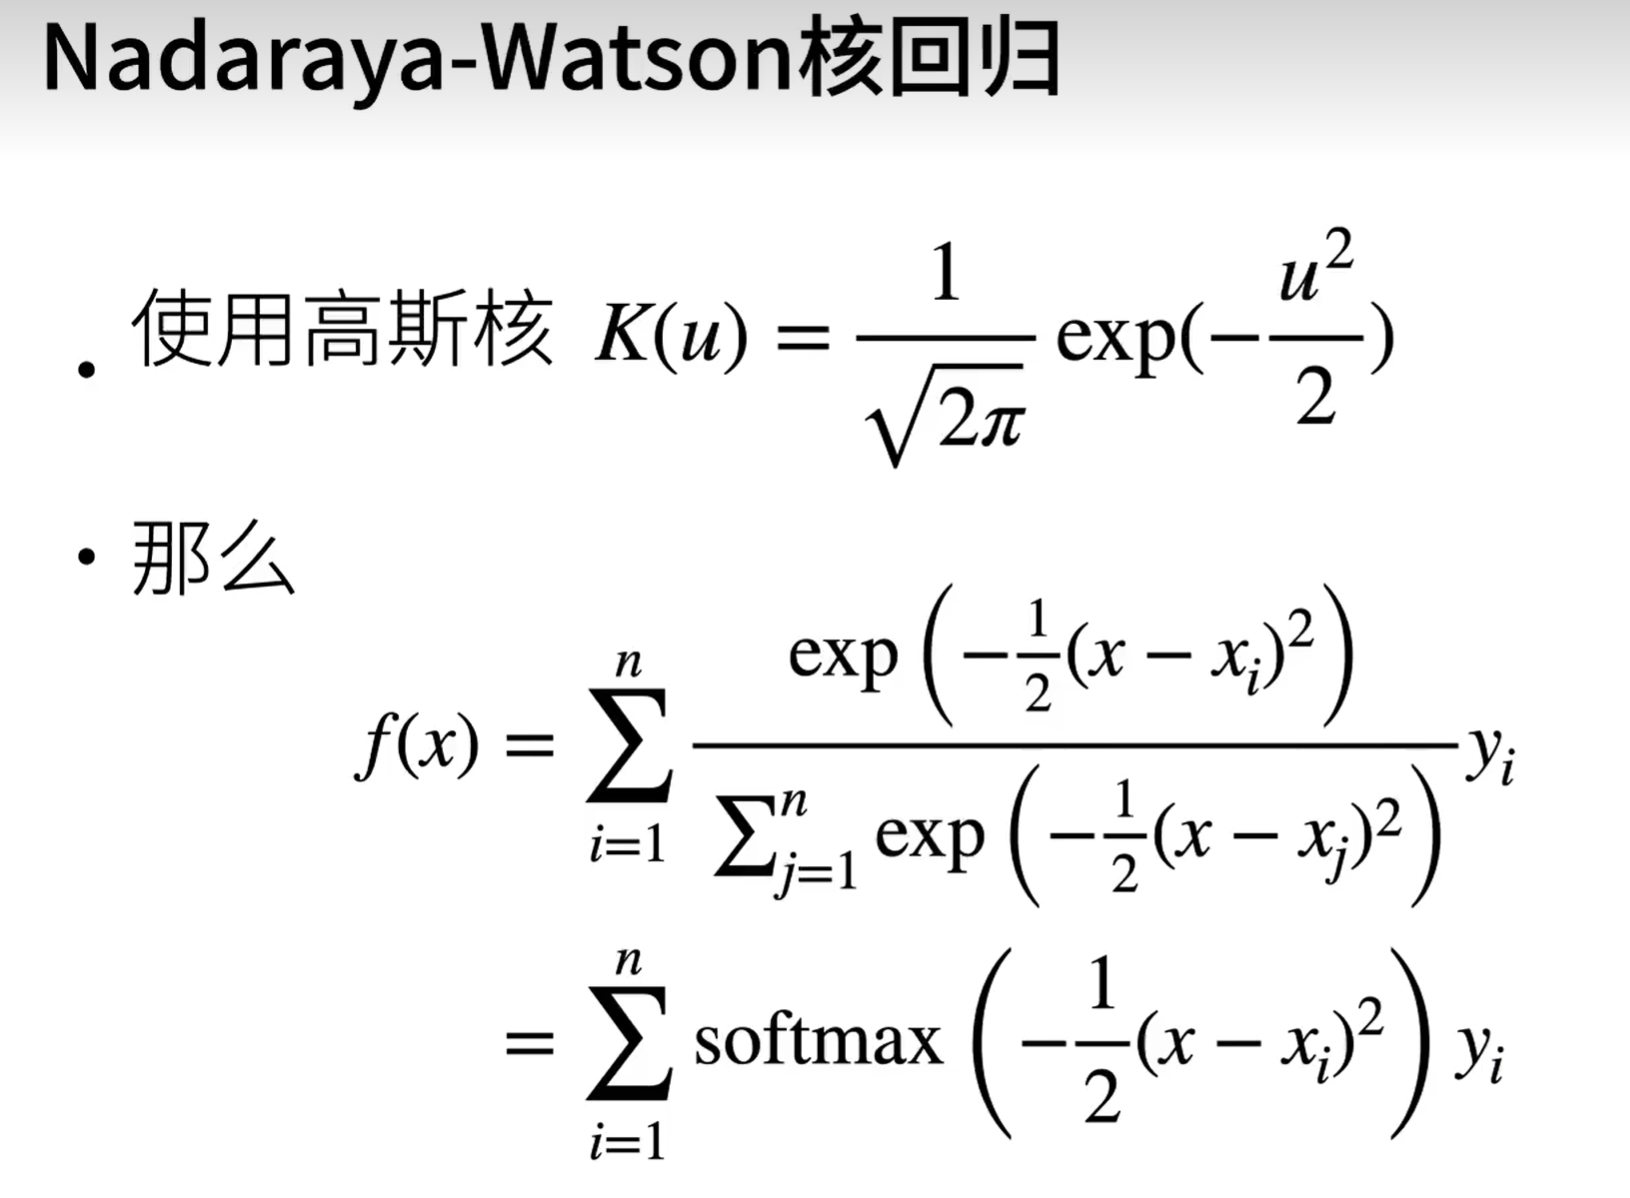
这里就是相当于求f(x)时，也就是求输入x后的预测值时会给已有的xj,yj键值对按照xj和当前x的距离，也就是关系远近分配权重，最后加权求对应的y_hat
核心就是根据现有数据点预测给出的x对应的y

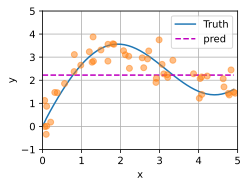

In [4]:
import torch
import d2l.torch as d2l
import torch.nn as nn

n_train = 50  # 已有的数据点数量
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # 已有的点的x


def f(x):
    return 2 * torch.sin(x) + x**0.8  # 真实的关系


# 生成已有点对应的y，normal：生成均值0,标准差0.5的高斯分布值，添加噪音，更符合现实情况
y_train = f(x_train) + torch.normal(
    0.0, 0.5, (n_train,)
)  # (n_train,)中的','别忘了加，指明shape
x_test = torch.arange(0, 5, 0.1)
y_truth = f(x_test)
n_test = len(x_test)


def plot_kernel_reg(y_hat):
    d2l.plot(
        x_test,
        [y_truth, y_hat],
        "x",
        "y",
        legend=["Truth", "pred"],
        xlim=[0, 5],
        ylim=[-1, 5],
    )
    d2l.plt.plot(x_train, y_train, "o", alpha=0.5)


y_hat = torch.repeat_interleave(
    y_train.mean(), n_test
)  # 最早的方法，直接返回现有y的均值
plot_kernel_reg(y_hat)

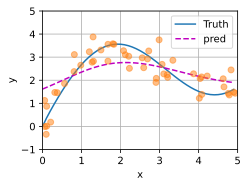

In [5]:
X_repeat = x_test.repeat_interleave(n_train).reshape(
    -1, n_train
)  # repeat：1,2,3->1,1,2,2,3,3
# 这里运算会发生广播，从最后一维开始对齐，X_repeat每行是一个测试x重复x_train次，
# 所以和x_train做运算x_train会广播为重复行到和X_repeat维度相同，
# 最终就是分别计算了每个测试点的权重序列并放在每一行
attention_weights = nn.functional.softmax(-((X_repeat - x_train) ** 2) / 2, dim=1)
y_hat = torch.matmul(
    attention_weights, y_train
)  # 一维向量作为左矩阵会被当作行向量，作为右矩阵会被当作列向量
# 算完后y_hat为一维向量
plot_kernel_reg(y_hat)

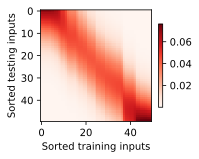

In [ ]:
# 这个函数要一个四维tensor,前两个是子图行数和子图列数，表明图片数量，后面两维是指每张子图的h和w
d2l.show_heatmaps(
    attention_weights.unsqueeze(0).unsqueeze(0),
    xlabel="Sorted training inputs",
    ylabel="Sorted testing inputs",
)

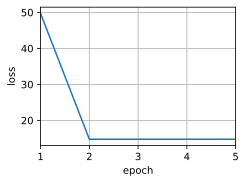

In [ ]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand(1))

    def forward(self, queries: torch.Tensor, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).view(-1, keys.shape[1])
        self.attention_weights = nn.functional.softmax(
            -(((queries - keys) * self.w) ** 2) / 2, dim=1
        )
        # 这里把weights矩阵的每一行变成行向量，values矩阵的每一行变成列向量，bmm函数的规则是把第0维看成batch,所以相当于一个矩阵数组，相乘时对应位置矩阵分别相乘，然后放到该位置。
        return torch.bmm(
            self.attention_weights.unsqueeze(1), values.unsqueeze(-1)
        ).reshape(-1)


# 因为我们这里采用leave-one-out，把已有数据又当作训练数据，所以要去掉每行和测试点完全相同的已有数据点，不然它训练时就光考虑和自己一样的那个点了，毕竟那个点距它太近了
# .type是类型转化，而torch.tensor的索引为torch.bool型时会触发高级索引，把true对应位置元素取出来构成新的一维序列
# repeat((a,b))第0维重复a次，第1维重复b次
keys = x_train.repeat((n_train, 1))[(1 - torch.eye(n_train)).type(torch.bool)].reshape(
    n_train, -1
)

values = y_train.repeat((n_train, 1))[
    (1 - torch.eye(n_train)).type(torch.bool)
].reshape(n_train, -1)
net = NWKernelRegression()
loss = nn.MSELoss(reduction="none")
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel="epoch", ylabel="loss", xlim=[1, 5])
for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f"epoch {epoch+1},loss {float(l.sum())}")
    animator.add(epoch + 1, float(l.sum()))

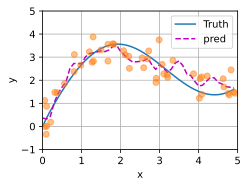

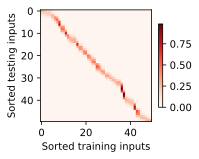

In [ ]:
keys = x_train.repeat((n_test, 1))
values = y_train.repeat((n_test, 1))
y_hat = net(
    x_test, keys, values
).detach()  # 这里一定要加.detach(),把它从计算图上分离出来，也就是把它的requires_grad设为False,因为画图时会有把它转为numpy的过程，而pytorch不允许将requires_grad=True的tensor转为numpy，所以会报错
plot_kernel_reg(y_hat)
d2l.show_heatmaps(
    net.attention_weights.unsqueeze(0).unsqueeze(0),
    xlabel="Sorted training inputs",
    ylabel="Sorted testing inputs",
)